# Mechanical P-Bit

In [1]:
import jax
import jax.numpy as jnp
from jax import random, vmap, grad, hessian
from scipy.stats import multivariate_normal
from scipy.linalg import inv, norm

import diffrax
import matplotlib.pyplot as plt

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

from oscillator_energies import energy_network

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


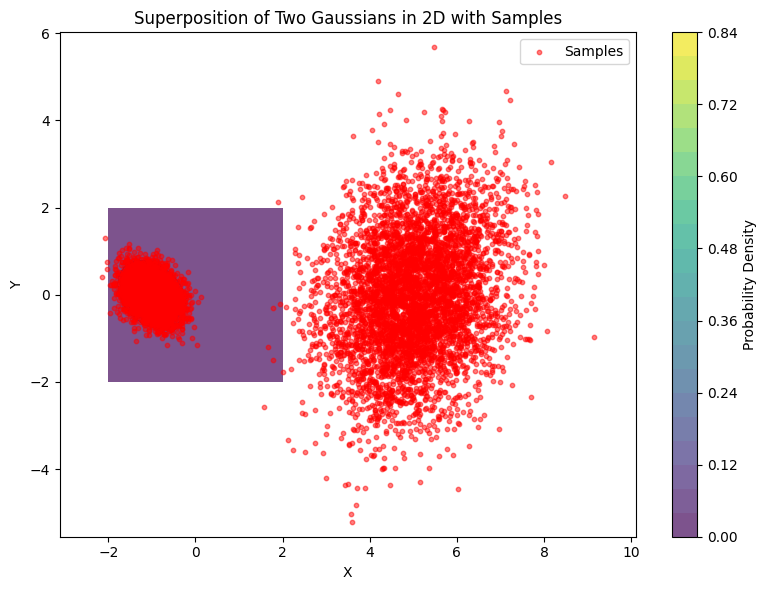

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([5, 0.0])
sigma1 = jnp.array([[1., -.4], [1.0, 2.]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = .5

# Number of samples to generate
n_samples = 10000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
# Compute variances of x1 and x2
x1_variance = jnp.var(samples[:, 0])
x2_variance = jnp.var(samples[:, 1])

print(f"Variance of x1: {x1_variance:.4f}")
print(f"Variance of x2: {x2_variance:.4f}")

# Also compute covariance for completeness
covariance = jnp.cov(samples.T)
print(f"\nFull covariance matrix:")
print(covariance)

Variance of x1: 9.6306
Variance of x2: 1.0302

Full covariance matrix:
[[9.63152142 0.09671234]
 [0.09671234 1.03027305]]


## 1. Define Parameters

In [4]:
m = jnp.array([1., 1.])
eig_freq = jnp.array([1., .1])
k_lin= eig_freq**2*m
k_duff = jnp.array([13., 5.])
c_lin = jnp.array([.1])
c_optomech = jnp.array([1.])
connectivity = jnp.array([[0, 1]])
damping = jnp.array([1., 1.])


k_b = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 1.             # Temperature (K)
 



In [5]:
energy_network_marg = energy_network
energy_network_x = lambda x: energy_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity,1.,1.)


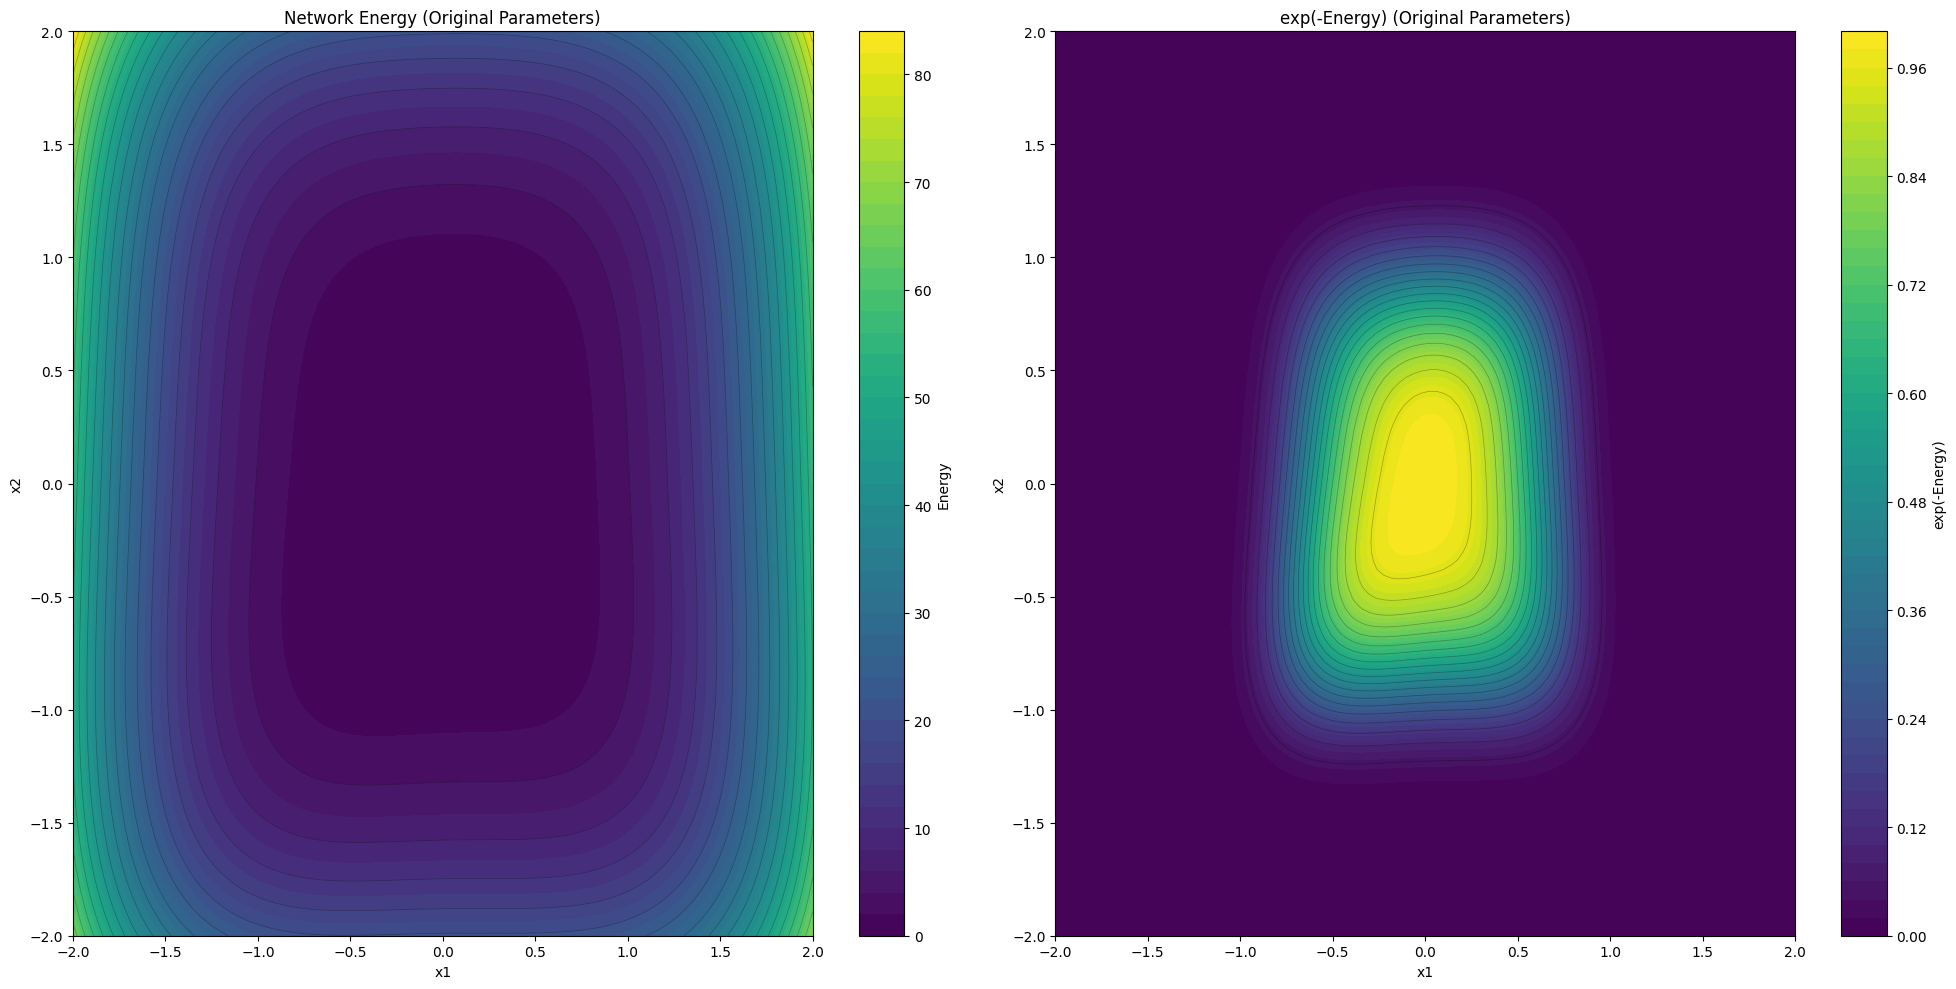

Original parameters: k_lin=[1.   0.01], k_duff=[13.  5.], c_lin=[0.1], c_optomech=[1.]
Integration limits: (-2, 2)


In [6]:
integration_limits = (-2, 2)
num_integration_points = 10
# Define the grid for plotting using integration limits
x1_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
x2_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original parameters
energy_values_original = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]), k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate exp(-energy) values
exp_neg_energy = jnp.exp(-energy_values_original)

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot original energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
ax1.set_title("Network Energy (Original Parameters)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
cbar1 = fig.colorbar(contour1, ax=ax1, label='Energy')

# Add contour lines for better visibility of energy levels
ax1.contour(X1, X2, energy_values_original, levels=20, colors='k', alpha=0.3, linewidths=0.5)

# Plot exp(-energy)
contour2 = ax2.contourf(X1, X2, exp_neg_energy, levels=50, cmap='viridis')
ax2.set_title("exp(-Energy) (Original Parameters)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
cbar2 = fig.colorbar(contour2, ax=ax2, label='exp(-Energy)')

# Add contour lines for better visibility of exp(-energy) levels
ax2.contour(X1, X2, exp_neg_energy, levels=20, colors='k', alpha=0.3, linewidths=0.5)

plt.tight_layout()
plt.show()

# Print original parameter values for reference
print(f"Original parameters: k_lin={k_lin}, k_duff={k_duff}, c_lin={c_lin}, c_optomech={c_optomech}")
print(f"Integration limits: {integration_limits}")

In [7]:
# Define lists of optimized and non-optimized parameters
optimized_params = [k_lin, k_duff,c_optomech,c_lin]
non_optimized_params = []

def loss_fn(*opt_params):
    # Combine optimized and non-optimized parameters
    all_params = list(opt_params) + non_optimized_params
    k_lin, k_duff, c_lin, c_optomech = all_params

    def current_network_energy(x):
        return energy_network_marg(x, k_lin, k_duff, c_lin, c_optomech, connectivity,k_b,T)
    
    current_score = grad(current_network_energy)
    current_score2 = hessian(current_network_energy)

    
    current_score_loss_per_sample = lambda x: (-jnp.trace(current_score2(x)) + 1/2 * jnp.sum(current_score(x)**2))   
    return jnp.sum(vmap(current_score_loss_per_sample)(samples))/n_samples

# Compute gradients of the loss with respect to optimized parameters
# @jit
def grad_loss(*opt_params):
    return grad(loss_fn, argnums=range(len(opt_params)))(*opt_params)


In [8]:
grad_loss(k_lin, k_duff, c_lin, c_optomech)

(Array([5162.05659658,   29.58543105], dtype=float64),
 Array([175438.64013001,    301.44660354], dtype=float64),
 Array([9941.49137034], dtype=float64),
 Array([2639.75855524], dtype=float64))

In [9]:
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    """
    x1, x2 = state
    return -inv(jnp.diag(damping))@grad(energy_network_x)(jnp.array([x1, x2]))


In [10]:
def compute_gradient_difference(samples, param_idx, dt, key, num_noise_samples=1000):
    """
    Computes the difference in energy gradients between current and averaged evolved+noise samples
    
    Args:
        samples: Input samples
        dt: Time step
        key: Random key
        num_noise_samples: Number of noise realizations to average over
    """
    
    # Compute current gradients (only need to do this once)
    grad_energy_curr = grad(energy_network_marg, argnums=(param_idx))
    grad_energy_x_curr = lambda x: grad_energy_curr(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b, T)
    grad_batch_curr = vmap(grad_energy_x_curr)
    current_grads = grad_batch_curr(samples)
    current_grads_avg = jnp.mean(current_grads, axis=0)
    
    
    # Get drift for all samples
    drift_batch = vmap(lambda x: drift_x_fn(0., x, None))
    drifts = drift_batch(samples)
    
    # Split key for multiple noise samples
    keys = random.split(key, num_noise_samples)
    
    # Function to compute evolved gradients for one noise realization
    def compute_evolved_grads(key):
        # Generate noise samples
        noise_std = jnp.sqrt(k_b*T*dt/damping)
        noise = random.normal(key, shape=samples.shape) * noise_std
        
        # Evolve samples with drift and noise
        evolved_samples = samples + drifts * dt/2 + noise
        
        # Compute energy gradients
        grad_energy = grad(energy_network_marg, argnums=(param_idx))
        grad_energy_x = lambda x: grad_energy(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b, T)
        grad_batch = vmap(grad_energy_x)
        
        return grad_batch(evolved_samples)
    
    
    
    # Compute and average evolved gradients over multiple noise realizations
    evolved_grads_all = vmap(compute_evolved_grads)(keys)  # Shape: (num_noise_samples, num_samples, ...)
    avg_evolved_grads = jnp.mean(evolved_grads_all, axis=0)  # Average over noise realizations
    # Compute difference using noise-averaged evolved gradients
    avg_grad_diff = current_grads_avg - jnp.mean(avg_evolved_grads, axis=0)
    
    return -avg_grad_diff



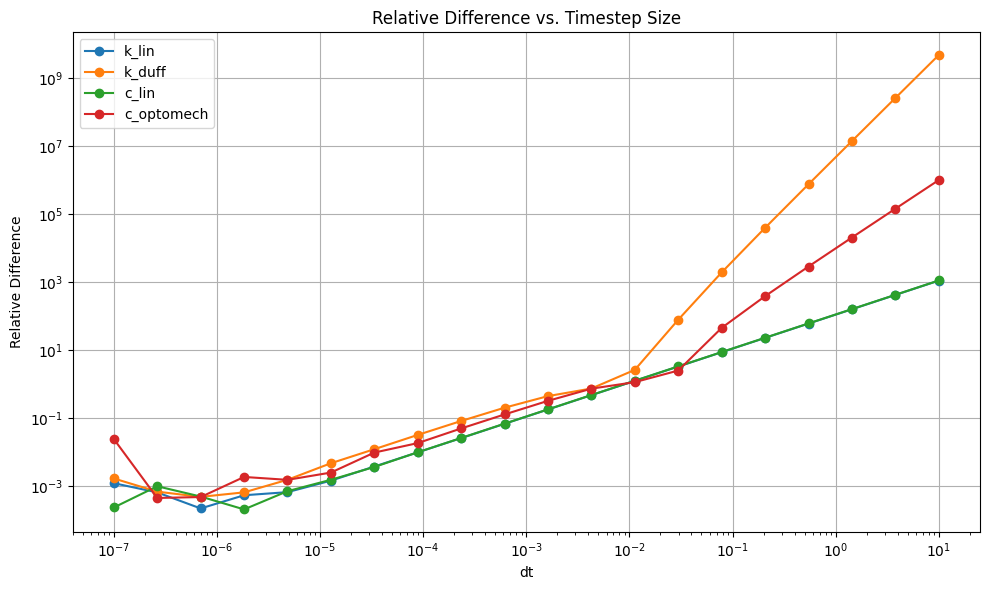


k_lin:
Minimum relative difference: 2.21e-04
Optimal dt: 6.95e-07

k_duff:
Minimum relative difference: 4.85e-04
Optimal dt: 6.95e-07

c_lin:
Minimum relative difference: 2.07e-04
Optimal dt: 1.83e-06

c_optomech:
Minimum relative difference: 4.50e-04
Optimal dt: 2.64e-07


In [11]:
# Compare gradient differences with grad_loss for different dt values
dt_values = jnp.logspace(-7, 1, 20)  # logarithmically spaced dt from 1e-5 to 1e-2
key = random.PRNGKey(1)

# Get grad_loss results (only need to compute once)
grad_loss_results = grad_loss(k_lin, k_duff, c_lin, c_optomech)

# Initialize arrays to store results
relative_differences = jnp.zeros((len(dt_values), 4))  # 4 parameters

# Loop over dt values
for i, dt in enumerate(dt_values):
    key, subkey = random.split(key)
    
    # Loop over parameter indices
    for param_idx in range(1,5):
        key, subkey = random.split(subkey)
        avg_gradient_diff = compute_gradient_difference(samples, param_idx, dt, subkey, num_noise_samples=1000)
        
        # Calculate relative difference
        rel_diff = jnp.mean(norm(-avg_gradient_diff/(dt/2) - grad_loss_results[param_idx-1]) / norm(grad_loss_results[param_idx-1]))
        relative_differences = relative_differences.at[i, param_idx-1].set(rel_diff)

# Plot results
plt.figure(figsize=(10, 6))
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
for param_idx in range(4):
    plt.loglog(dt_values, relative_differences[:, param_idx], 'o-', label=param_names[param_idx])

plt.xlabel('dt')
plt.ylabel('Relative Difference')
plt.title('Relative Difference vs. Timestep Size')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print the minimum relative difference and corresponding dt for each parameter
for param_idx in range(4):
    min_idx = jnp.argmin(relative_differences[:, param_idx])
    print(f"\n{param_names[param_idx]}:")
    print(f"Minimum relative difference: {relative_differences[min_idx, param_idx]:.2e}")
    print(f"Optimal dt: {dt_values[min_idx]:.2e}")